Gradient Boosting RMSE: 76.45497344683835
Gradient Boosting MAE: 64.2812113280321


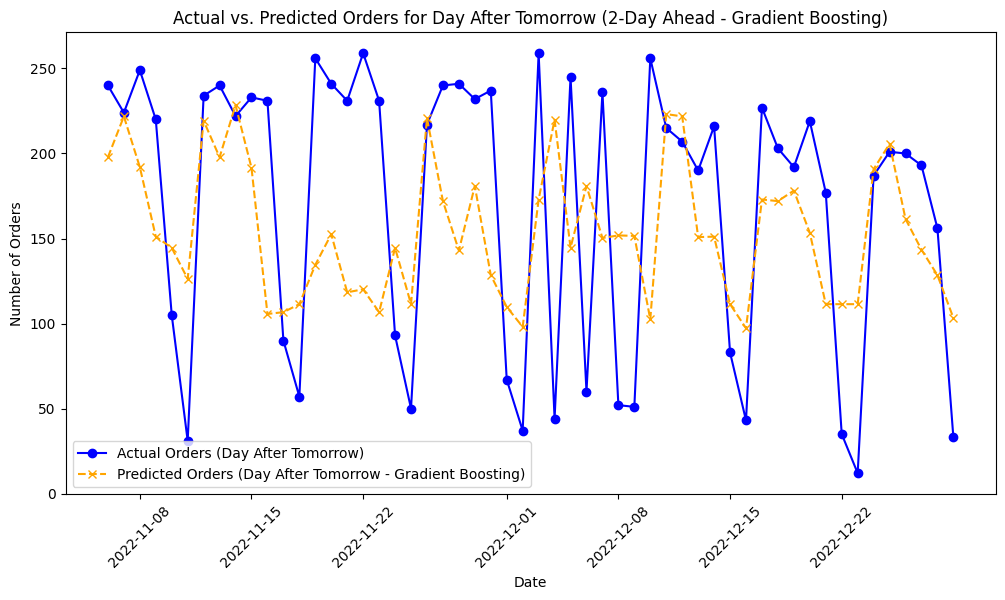

In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load and preprocess the data
file_path = '/content/ConteoDias.xlsx'
data = pd.read_excel(file_path)
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]
data['fecha'] = pd.to_datetime(data['fecha'])

# Add day of the week column (0 = Monday, 6 = Sunday) and create weekend indicator
data['day_of_week'] = data['fecha'].dt.dayofweek
data['is_weekend'] = data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Create lagged weather features, order lags, and target column
data['prcp_lag1'] = data['prcp'].shift(1)  # Yesterday's rain
data['orders_lag1'] = data['pedidos'].shift(1)  # Orders 1 day prior
data['orders_lag2'] = data['pedidos'].shift(2)  # Orders 2 days prior
data['orders_day_after'] = data['pedidos'].shift(-2)  # Orders two days ahead
data_model = data.dropna().reset_index(drop=True)  # Drop rows with NaN values

# Step 3: Define features and target for 2-day ahead prediction
X_features = data_model[['tavg', 'prcp', 'wspd', 'prcp_lag1', 'is_weekend', 'orders_lag1', 'orders_lag2']]
y_day_after_updated = data_model['orders_day_after']

# Split data into training and testing sets (80% training, 20% testing)
train_size = int(len(X_features) * 0.8)
X_train_feat, X_test_feat = X_features[:train_size], X_features[train_size:]
y_train_day_after_feat, y_test_day_after_feat = y_day_after_updated[:train_size], y_day_after_updated[train_size:]

# Step 4: Initialize and train the Gradient Boosting model with modified parameters
gb_model = GradientBoostingRegressor(
    n_estimators=200,       # Increased number of boosting stages
    learning_rate=0.01,     # Lower learning rate for better accuracy
    max_depth=3,            # Maximum depth of individual trees
    random_state=42         # Ensures reproducibility
)
gb_model.fit(X_train_feat, y_train_day_after_feat)

# Step 5: Make predictions on the test set
y_pred_gb_day_after = gb_model.predict(X_test_feat)

# Step 6: Evaluate the model
rmse_gb = np.sqrt(mean_squared_error(y_test_day_after_feat, y_pred_gb_day_after))
mae_gb = mean_absolute_error(y_test_day_after_feat, y_pred_gb_day_after)
print(f"Gradient Boosting RMSE: {rmse_gb}")
print(f"Gradient Boosting MAE: {mae_gb}")

# Step 7: Plot actual vs predicted orders for 2-day ahead forecast
plt.figure(figsize=(12, 6))
plt.plot(data_model['fecha'][y_test_day_after_feat.index], y_test_day_after_feat,
         label='Actual Orders (Day After Tomorrow)', color='blue', marker='o')
plt.plot(data_model['fecha'][y_test_day_after_feat.index], y_pred_gb_day_after,
         label='Predicted Orders (Day After Tomorrow - Gradient Boosting)', color='orange', linestyle='--', marker='x')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.title('Actual vs. Predicted Orders for Day After Tomorrow (2-Day Ahead - Gradient Boosting)')
plt.legend()
plt.xticks(rotation=45)
plt.show()